# Модуль 1. Введение в сбор данных

- [X] Соберать данные из двух разных источников (открытый датасет + веб-скрейпинг или API).
- [X] Провести их агрегацию, создав единый датасет. Ссылка на архив с новостями из forbesrussia и на единый датасет (news.csv). https://drive.google.com/file/d/1ZIQYHF1ohU4Bg0XHlVyc4dwHD86gHc7T/view?usp=sharing`
- [X] Провести разведывательный анализ данных (EDA).
- [X]  Постройть базовые визуализации для основных признаков с учетом разметки данных.
- [X] Описать возможные применения этих данных в контексте машинного обучения.


# Описание датасета
### Идея:

Собрать новостные данные за определенный промежуток времени для получения кластеризации компаний по их наименованиям. Соответственно, решается 2 задачи. Первая - сбор новостных постов, вторая - извлечение названий компаний. В рамках PoC решения будут собраны только новостные посты для их дальнейшей кластеризации.

### Реализация:

  - Первой задачей (решаемая сейчас) будет парсинг новостных Telegram-каналов для получения постов, обогащение датасета открытыми датасетами.
  - Второй задачей (MVP-итерация) - разметка названий упоминаемых компаний для решения NER на новостных постах, обогащение открытыми датасетами

В связи с тем, что асинхронное исполенение кода в Jupyter-notebooks не работает, исполняемый код с парсингом записан в файле `src/data/parse.py`. Мы парсим канал "forbesrussia" за последний 21 день и кладем данные в `data/raw/forbes-news.csv`, получили 886 новостных записей. В качестве открытого датасета взяли `yutkin/Lenta.Ru-News-Dataset`, содержащего 800964 новостных записей. Для упрощения себе жизни, будем использовать 1000 последних записей


### Применение для машинного обучения:

Кластеризации новостей по их содержимому для поиска инфо-поводов.

### Алгоритм обработки:

1. Парсинг постов Telegram-канала forbesrussia за последний 21 день и последующие сохранение в .csv файл.
2. Загрузка открытого датасета с новостями Lenta-Ru, использование последних 1000 строк.
3. Изменение формата даты и объедиинение датасетов в единый.
4. Удаление пропусков 
5. Токенизация для дальнейшего статистического анализа.


In [18]:
from pathlib import Path
import os

import pandas as pd
from razdel import tokenize
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [2]:
RAW_PATH = Path(r"..\data\raw").as_posix()
PROCESSED_PATH = Path(r"..\data\processed").as_posix()
INTERIM_PATH = Path(r"..\data\interim").as_posix()
EXTERNAL_PATH = Path(r"..\data\external").as_posix()

assert (
    os.path.isdir(RAW_PATH)
    and os.path.isdir(PROCESSED_PATH)
    and os.path.isdir(INTERIM_PATH)
    and os.path.isdir(EXTERNAL_PATH)
)

# 1. Проведем агрегацию данных и создадим единый датасет


In [ ]:
# Используем последние 1000 записей из датасета Lenta.Ru-News-Dataset, только текст и дату

lenta_df = pd.read_csv(
    Path(RAW_PATH / Path("lenta-ru-news.csv")), usecols=["date", "text"]
).tail(1000)
forbes_df = pd.read_csv(
    Path(RAW_PATH / Path("forbes-news.csv")), usecols=["date", "text"]
)

# Преобразуем даты в формат YYYY-MM-DD
lenta_df["date"] = pd.to_datetime(lenta_df["date"]).dt.strftime("%Y-%m-%d")
forbes_df["date"] = pd.to_datetime(forbes_df["date"]).dt.strftime("%Y-%m-%d")


# Конкатенируем датасеты и сохраняем в csv
news_df = pd.concat([lenta_df, forbes_df], ignore_index=True)
news_df.to_csv(Path(RAW_PATH / Path("news.csv")), index=False)

In [4]:
# Загрузим датасет из csv

news_df = pd.read_csv(Path(RAW_PATH / Path("news.csv")))
news_df.tail()

,text,date
1881,Турецкие рынки резко рухнули после задержания ...,2025-03-19
1882,Россия и Украина провели обмен военнослужащими...,2025-03-19
1883,Инфляционные ожидания россиян в марте снизилис...,2025-03-19
1884,Генпрокуратура проверит работу МЧС и его подра...,2025-03-19
1885,Национальный союз защиты прав потребителей поп...,2025-03-19


# 2. Проведем разведочный анализ данных (EDA)

In [ ]:
# Посмотрим на данные с помощью библиотеки ydata_profiling

from ydata_profiling import ProfileReport

In [25]:
profile = ProfileReport(news_df, title="YData Profiling Report")
profile.to_notebook_iframe()

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 10.25it/s]


In [ ]:
# Удаляем строки, где столбец "text" содержит NaN значения
news_df = news_df.dropna(subset=["text"])
print(f"Размер датасета после удаления NaN: {news_df.shape[0]} строк")
print(f"Пустых строк:{news_df['text'].isna().sum()}")


In [15]:
# Подсчетаем количество токенов в тексте
def count_tokens(text):
    if isinstance(text, str):
        return len(list(tokenize(text)))
    return 0


# Создаем новый столбец с количеством токенов для каждой новости
news_df["token_count"] = news_df["text"].apply(count_tokens)

# Выводим первые несколько строк для проверки
print(f"Среднее количество токенов: {news_df['token_count'].mean():.2f}")
print(f"Максимальное количество токенов: {news_df['token_count'].max()}")
print(f"Минимальное количество токенов: {news_df['token_count'].min()}")

Среднее количество токенов: 153.15
Максимальное количество токенов: 722
Минимальное количество токенов: 21


# 3. Построим базовые визуализации для основных признаков с учетом разметки данных

C:\Users\vallo\AppData\Local\Temp\ipykernel_25980\4208502352.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(news_df['token_count'],color='g',shade=True)


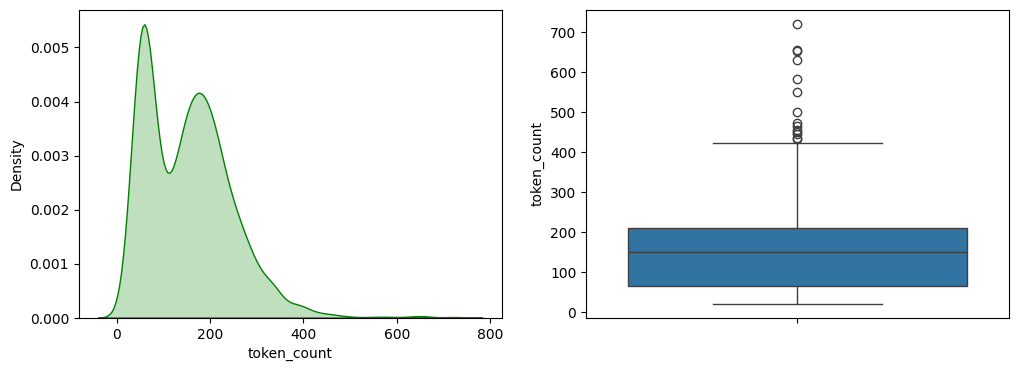

In [ ]:
# Посмотрим на распределение количества токено в текстах

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(news_df["token_count"], color="g", shade=True)
plt.subplot(1, 2, 2)
sns.boxplot(news_df["token_count"])
plt.show()


**Видим, что очень малое количество новостей имеют двойное количество токенов в тексте по сравнению с остальными, но даже максимум не такой большой и проблем переводом в эмбеддинги не должно быть**

In [27]:
# Посмотрим на выбросы с точки щрения стандарного отклонения

y_outliers = news_df[abs(zscore(news_df["token_count"])) >= 3]
y_outliers.shape[0]

14

**Новостей с количеством токенов, не попадающих в интервал $[-3\sigma, 3\sigma]$ немного и, что самое важное - среди выбросов просто длинные тексты**

# 4. Опишем возможные применения этих данных в контексте машинного обучения

**Дальнейший пайплайн работы с данными**:
- Токенизация, лемматизация, удаление стоп-слов
- Векторизация текста с помощью  `sentence-transformers`
- Кластеризация с помощью `HDBSCAN` 
- Присвоение имен кластерам
- Привязка по времени
- Графическая визуализация
- Оптимизация алгоритмов под промышленное использование 